# Monte Carlo Option Pricing Engine
**Author:** Yash  
Institutional-style Google Colab notebook.

In [2]:
!pip -q install yfinance

## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm


## Download Market Data

In [4]:
ticker='NVDA'
df=yf.download(ticker,period='3y',progress=False)
prices=df['Close'].dropna()
returns=np.log(prices/prices.shift(1)).dropna()
sigma=float(returns.std()*np.sqrt(252))
S0=float(prices.iloc[-1])
r=0.05
T=1
K=round(S0)
print(S0,sigma)


/tmp/ipykernel_1823/631019831.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker,period='3y',progress=False)


206.83999633789062 0.4681422071829758


/tmp/ipykernel_1823/631019831.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma=float(returns.std()*np.sqrt(252))
/tmp/ipykernel_1823/631019831.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0=float(prices.iloc[-1])


## Black-Scholes

In [5]:
def black_scholes_call(S,K,T,r,sigma):
    d1=(np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2=d1-sigma*np.sqrt(T)
    return S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)

bs=black_scholes_call(S0,K,T,r,sigma)
print(bs)


42.53086303466344


## Monte Carlo European Option

In [6]:
np.random.seed(42)
N=100000
Z=np.random.randn(N)
ST=S0*np.exp((r-0.5*sigma**2)*T+sigma*np.sqrt(T)*Z)
payoff=np.maximum(ST-K,0)
mc=np.exp(-r*T)*payoff.mean()
print("MC:",mc,"BS:",bs)


MC: 42.64147871086441 BS: 42.53086303466344


## GBM Paths

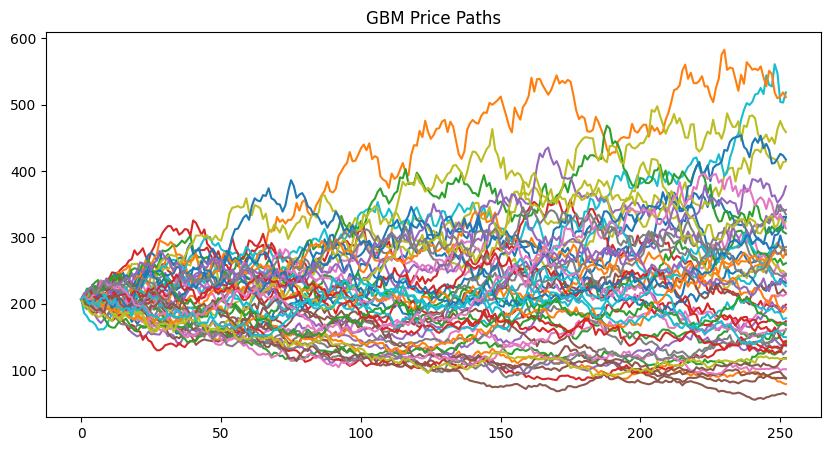

In [7]:
steps=252
paths=50
dt=T/steps
S=np.zeros((steps+1,paths))
S[0]=S0
for i in range(1,steps+1):
    z=np.random.randn(paths)
    S[i]=S[i-1]*np.exp((r-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*z)
plt.figure(figsize=(10,5))
plt.plot(S)
plt.title("GBM Price Paths")
plt.show()


## Terminal Distribution

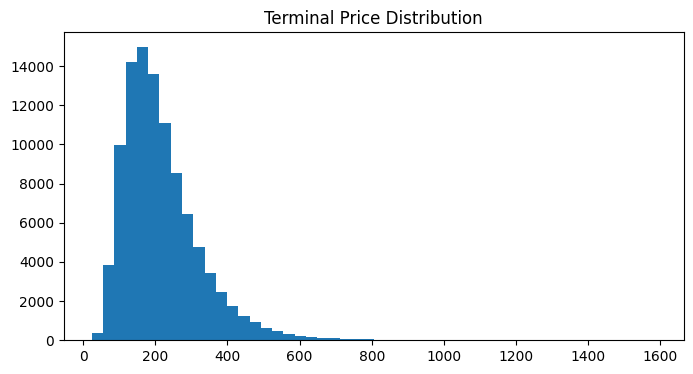

In [8]:
plt.figure(figsize=(8,4))
plt.hist(ST,bins=50)
plt.title("Terminal Price Distribution")
plt.show()


## Asian Option

In [9]:
steps=252
dt=T/steps
Z=np.random.randn(N,steps)
logS=np.log(S0)+np.cumsum((r-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*Z,axis=1)
paths=np.exp(logS)
avg=paths.mean(axis=1)
asian=np.exp(-r*T)*np.maximum(avg-K,0).mean()
print("Asian Call:",asian)


Asian Call: 23.920555395764975


## Summary

In [10]:
summary=pd.DataFrame({
    "Metric":["Spot","Strike","Volatility","BS Call","MC Call","Asian Call"],
    "Value":[S0,K,sigma,bs,mc,asian]
})
summary


,Metric,Value
0,Spot,206.839996
1,Strike,207.000000
2,Volatility,0.468142
3,BS Call,42.530863
4,MC Call,42.641479
5,Asian Call,23.920555
